In [10]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
conn = sqlite3.connect("ecommerce.db")
cursor = conn.cursor()

In [12]:
print("Database connected successfully!")

Database connected successfully!


In [13]:
cursor.execute("""CREATE TABLE IF NOT EXISTS Customers 
(
    CustomerID INTEGER PRIMARY KEY,
    CustomerName TEXT,
    City TEXT
)
""")

conn.commit()

print("Customers table created successfully!")

Customers table created successfully!


In [14]:
cursor.execute("""CREATE TABLE IF NOT EXISTS Products 
(
    ProductID INTEGER PRIMARY KEY,
    ProductName TEXT,
    Category TEXT,
    Price REAL
)
""")

conn.commit()

print("Products table created successfully!")

Products table created successfully!


In [15]:
cursor.execute("""CREATE TABLE IF NOT EXISTS Orders 
(
    OrderID INTEGER PRIMARY KEY,
    CustomerID INTEGER,
    ProductID INTEGER,
    Quantity INTEGER,
    OrderDate TEXT,
    FOREIGN KEY(CustomerID) REFERENCES Customers(CustomerID),
    FOREIGN KEY(ProductID) REFERENCES Products(ProductID)
)
""")

conn.commit()

print("Orders table created successfully!")

Orders table created successfully!


In [16]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql_query(query, conn)
tables

,name
0,Customers
1,Products
2,Orders


In [19]:
customers = [
    (10, 'Joel', 'Chennai'),
    (20, 'Vishali', 'Bangalore'),
    (30, 'Aruna', 'Hyderabad'),
    (40, 'Snehan', 'Mumbai'),
    (50, 'Kiara', 'Delhi')
]

cursor.executemany("""
INSERT INTO Customers
VALUES (?, ?, ?)
""", customers)

conn.commit()

print("Customers data inserted successfully!")

Customers data inserted successfully!


In [18]:
df = pd.read_sql_query("SELECT * FROM Customers", conn)

df

,CustomerID,CustomerName,City
0,1,Rahul,Chennai
1,2,Priya,Bangalore
2,3,Arun,Hyderabad
3,4,Sneha,Mumbai
4,5,Kiran,Delhi


In [ ]:
products = [
    (101, 'Laptop', 'Electronics', 65000),
    (102, 'Smartphone', 'Electronics', 30000),
    (103, 'Headphones', 'Accessories', 2500),
    (104, 'Office Chair', 'Furniture', 7000),
    (105, 'Keyboard', 'Accessories', 1500)
]

cursor.executemany("""
INSERT INTO Products
VALUES (?, ?, ?, ?)
""", products)

conn.commit()

print("Products data inserted successfully!")

In [13]:
df = pd.read_sql_query("SELECT * FROM Products", conn)

df

,ProductID,ProductName,Category,Price
0,101,Laptop,Electronics,65000.0
1,102,Smartphone,Electronics,30000.0
2,103,Headphones,Accessories,2500.0
3,104,Office Chair,Furniture,7000.0
4,105,Keyboard,Accessories,1500.0


In [14]:
orders = [
    (1001, 1, 101, 1, '2026-01-10'),
    (1002, 2, 103, 2, '2026-01-11'),
    (1003, 3, 102, 1, '2026-01-12'),
    (1004, 4, 104, 1, '2026-01-13'),
    (1005, 5, 105, 3, '2026-01-14'),
    (1006, 1, 103, 1, '2026-01-15'),
    (1007, 2, 101, 1, '2026-01-16'),
    (1008, 3, 105, 2, '2026-01-17')
]

cursor.executemany("""
INSERT INTO Orders
VALUES (?, ?, ?, ?, ?)
""", orders)

conn.commit()

print("Orders data inserted successfully!")

Orders data inserted successfully!


In [15]:
df = pd.read_sql_query("SELECT * FROM Orders", conn)
df

,OrderID,CustomerID,ProductID,Quantity,OrderDate
0,1001,1,101,1,2026-01-10
1,1002,2,103,2,2026-01-11
2,1003,3,102,1,2026-01-12
3,1004,4,104,1,2026-01-13
4,1005,5,105,3,2026-01-14
5,1006,1,103,1,2026-01-15
6,1007,2,101,1,2026-01-16
7,1008,3,105,2,2026-01-17


In [16]:
query = """
SELECT City, COUNT(*) AS Total_Customers
FROM Customers
GROUP BY City
"""

In [17]:
city_df = pd.read_sql_query(query, conn)

city_df

,City,Total_Customers
0,Bangalore,1
1,Chennai,1
2,Delhi,1
3,Hyderabad,1
4,Mumbai,1


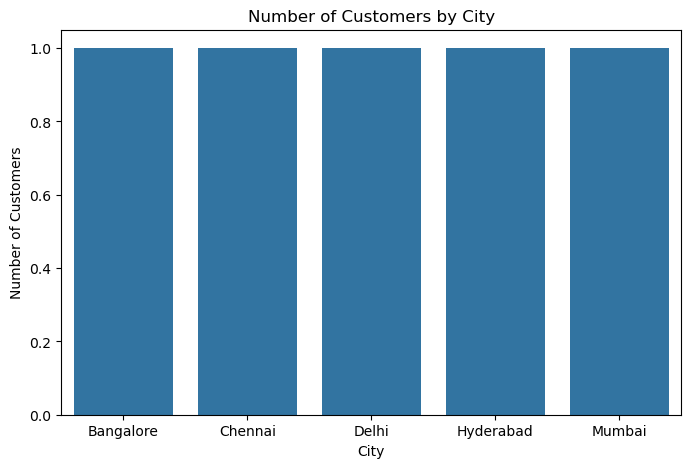

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(data=city_df,
            x='City',
            y='Total_Customers')

plt.title("Number of Customers by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.show()


In [ ]:
Observation: Each city currently has one customer, so the bar chart shows equal customer counts across all cities.

In [19]:
query = """
SELECT
    Products.ProductName,
    SUM(Orders.Quantity) AS Total_Sold
FROM Orders
JOIN Products
ON Orders.ProductID = Products.ProductID
GROUP BY Products.ProductName
ORDER BY Total_Sold DESC
"""

In [20]:
product_df = pd.read_sql_query(query, conn)

product_df

,ProductName,Total_Sold
0,Keyboard,5
1,Headphones,3
2,Laptop,2
3,Smartphone,1
4,Office Chair,1


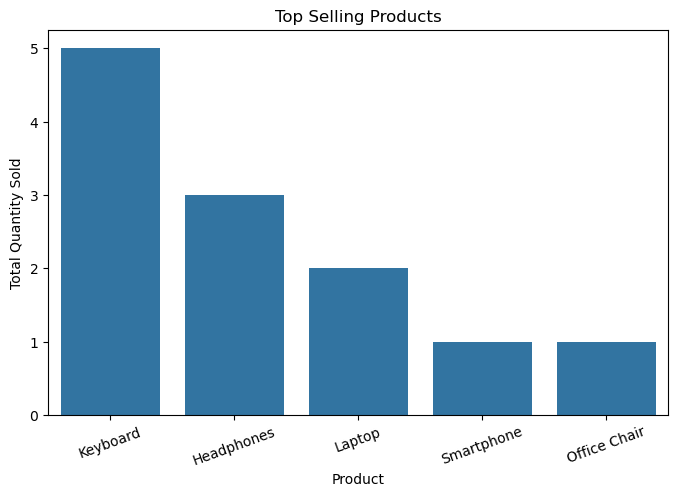

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=product_df,
    x='ProductName',
    y='Total_Sold'
)

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=20)

plt.show()

In [22]:
query = """
SELECT
    Products.Category,
    SUM(Products.Price * Orders.Quantity) AS Revenue
FROM Orders
JOIN Products
ON Orders.ProductID = Products.ProductID
GROUP BY Products.Category
ORDER BY Revenue DESC
"""

In [23]:
category_df = pd.read_sql_query(query, conn)

category_df

,Category,Revenue
0,Electronics,160000.0
1,Accessories,15000.0
2,Furniture,7000.0


In [31]:
query = """
SELECT
    Products.Category,
    SUM(Products.Price * Orders.Quantity) AS Revenue
FROM Orders
JOIN Products
ON Orders.ProductID = Products.ProductID
GROUP BY Products.Category
"""

category_df = pd.read_sql_query(query, conn)

In [25]:
query = """
SELECT
    Customers.CustomerName,
    SUM(Products.Price * Orders.Quantity) AS Total_Spending
FROM Orders
JOIN Customers
ON Orders.CustomerID = Customers.CustomerID
JOIN Products
ON Orders.ProductID = Products.ProductID
GROUP BY Customers.CustomerName
ORDER BY Total_Spending DESC
"""

In [26]:
customer_df = pd.read_sql_query(query, conn)

customer_df

,CustomerName,Total_Spending
0,Priya,70000.0
1,Rahul,67500.0
2,Arun,33000.0
3,Sneha,7000.0
4,Kiran,4500.0


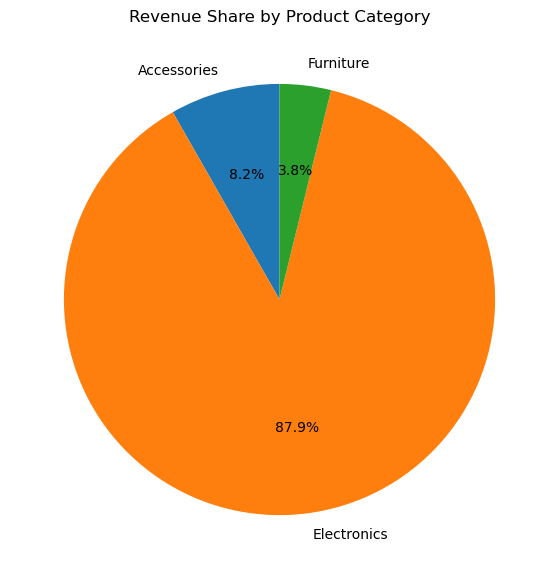

In [32]:
plt.figure(figsize=(7,7))

plt.pie(
    category_df["Revenue"],
    labels=category_df["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Product Category")

plt.show()

In [28]:
query = """
SELECT
    OrderDate,
    SUM(Quantity) AS Total_Items_Sold
FROM Orders
GROUP BY OrderDate
ORDER BY OrderDate
"""

In [29]:
sales_df = pd.read_sql_query(query, conn)

sales_df

,OrderDate,Total_Items_Sold
0,2026-01-10,1
1,2026-01-11,2
2,2026-01-12,1
3,2026-01-13,1
4,2026-01-14,3
5,2026-01-15,1
6,2026-01-16,1
7,2026-01-17,2


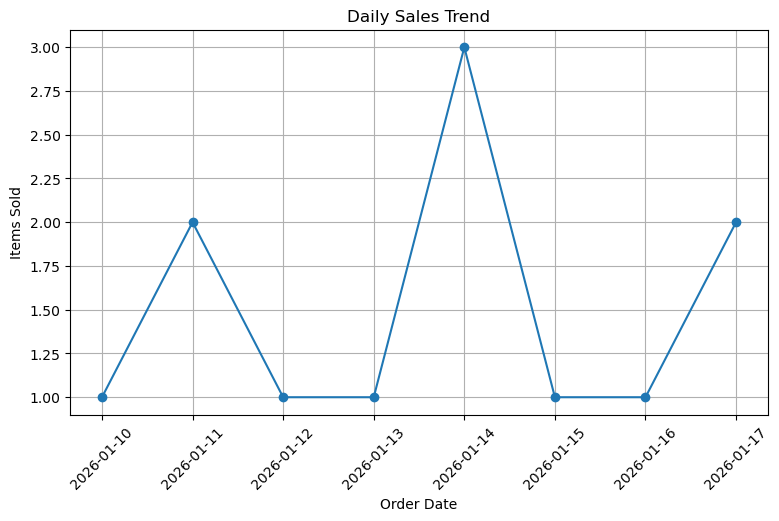

In [30]:
plt.figure(figsize=(9,5))

plt.plot(
    sales_df["OrderDate"],
    sales_df["Total_Items_Sold"],
    marker="o"
)

plt.title("Daily Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Items Sold")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

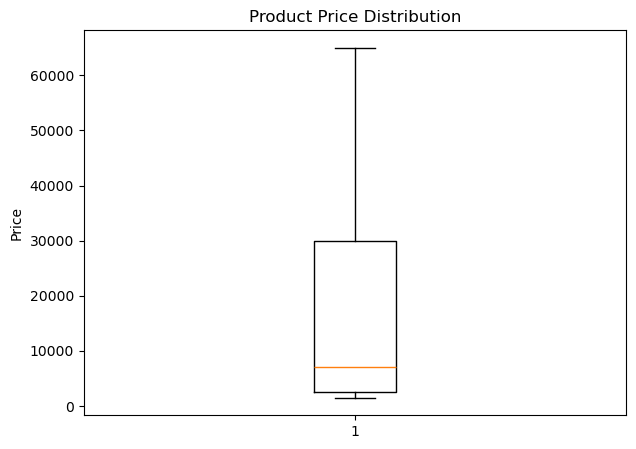

In [38]:
product_df = pd.read_sql_query(
    "SELECT Price FROM Products",
    conn
)

plt.figure(figsize=(7,5))

plt.boxplot(product_df["Price"])

plt.title("Product Price Distribution")
plt.ylabel("Price")

plt.show()

In [34]:
query = """
SELECT
Products.ProductName,
Products.Price,
Orders.Quantity
FROM Orders
JOIN Products
ON Orders.ProductID = Products.ProductID
"""

scatter_df = pd.read_sql_query(query, conn)

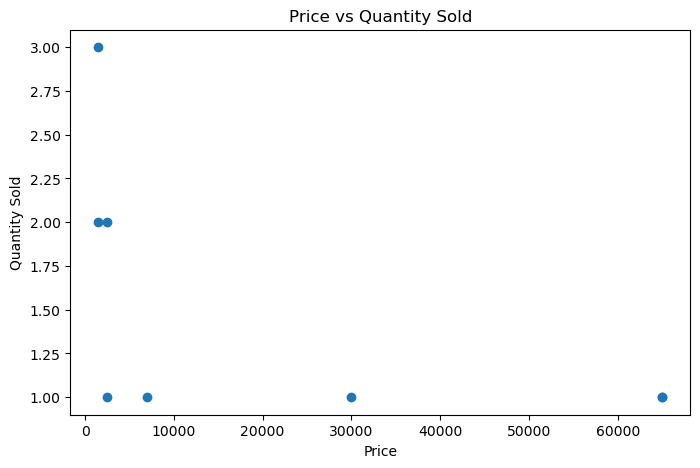

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(
    scatter_df["Price"],
    scatter_df["Quantity"]
)

plt.title("Price vs Quantity Sold")

plt.xlabel("Price")

plt.ylabel("Quantity Sold")

plt.show()

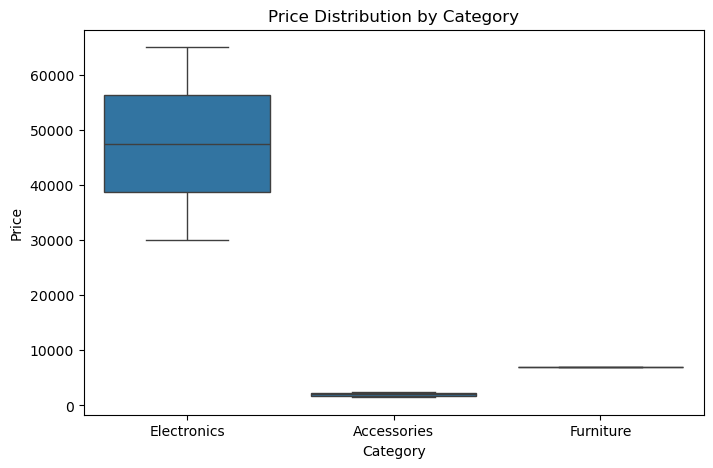

In [36]:
product_df = pd.read_sql_query(
    "SELECT Category, Price FROM Products",
    conn
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=product_df,
    x="Category",
    y="Price"
)

plt.title("Price Distribution by Category")

plt.show()

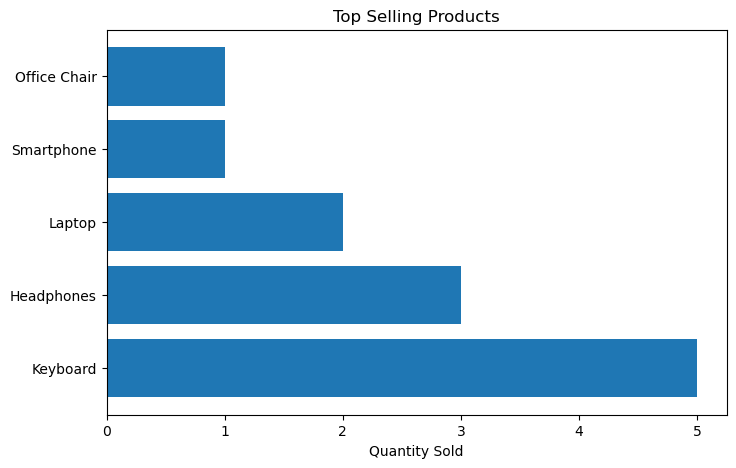

In [37]:
query = """
SELECT
Products.ProductName,
SUM(Orders.Quantity) AS TotalSold
FROM Orders
JOIN Products
ON Orders.ProductID = Products.ProductID
GROUP BY Products.ProductName
ORDER BY TotalSold DESC
"""

top_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))

plt.barh(
    top_df["ProductName"],
    top_df["TotalSold"]
)

plt.title("Top Selling Products")

plt.xlabel("Quantity Sold")

plt.show()

In [9]:
conn.close()